<a href="https://colab.research.google.com/github/MindfulTechie-06/Ai-MoodJournal/blob/main/Route.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problem 3: Checking Routes Between Cities Using DFS

We will represent the road network as an undirected graph, where cities are nodes and roads are edges. An adjacency list will be used to store the graph, where each city maps to a list of cities it is directly connected to.

In [1]:
# Define the road network (graph) using Indian city names
# This is an undirected graph, so connections are bidirectional.
road_network = {
    'Delhi': ['Mumbai', 'Jaipur'],
    'Mumbai': ['Delhi', 'Bengaluru', 'Ahmedabad'],
    'Jaipur': ['Delhi', 'Udaipur'],
    'Bengaluru': ['Mumbai', 'Chennai', 'Hyderabad'],
    'Chennai': ['Bengaluru', 'Hyderabad'],
    'Hyderabad': ['Bengaluru', 'Chennai'],
    'Ahmedabad': ['Mumbai'],
    'Kolkata': ['Bhubaneswar'],
    'Bhubaneswar': ['Kolkata']
}

In [2]:
def check_route(graph, start_city, end_city):
    """
    Checks if a route exists between two cities using DFS.
    """
    if start_city not in graph or end_city not in graph:
        return False

    visited = set()
    stack = [start_city]

    while stack:
        current_city = stack.pop()
        if current_city == end_city:
            return True
        if current_city not in visited:
            visited.add(current_city)
            for neighbor in graph.get(current_city, []):
                if neighbor not in visited:
                    stack.append(neighbor)
    return False

In [3]:
def find_connected_components(graph):
    """
    Finds all separate groups of cities that are connected to each other.
    """
    visited = set()
    components = []

    for city in graph:
        if city not in visited:
            current_component = set()
            stack = [city]
            visited.add(city)

            while stack:
                node = stack.pop()
                current_component.add(node)
                for neighbor in graph.get(node, []):
                    if neighbor not in visited:
                        visited.add(neighbor)
                        stack.append(neighbor)
            components.append(sorted(list(current_component)))
    return components

### Demonstrating Route Checking

In [4]:
# Test cases for route checking
print("Route from Delhi to Chennai exists:", check_route(road_network, 'Delhi', 'Chennai'))
print("Route from Delhi to Kolkata exists:", check_route(road_network, 'Delhi', 'Kolkata'))
print("Route from Mumbai to Ahmedabad exists:", check_route(road_network, 'Mumbai', 'Ahmedabad'))
print("Route from Jaipur to Bengaluru exists:", check_route(road_network, 'Jaipur', 'Bengaluru'))
print("Route from Kolkata to Bhubaneswar exists:", check_route(road_network, 'Kolkata', 'Bhubaneswar'))
print("Route from Bengaluru to Delhi exists:", check_route(road_network, 'Bengaluru', 'Delhi'))

Route from Delhi to Chennai exists: True
Route from Delhi to Kolkata exists: False
Route from Mumbai to Ahmedabad exists: True
Route from Jaipur to Bengaluru exists: True
Route from Kolkata to Bhubaneswar exists: True
Route from Bengaluru to Delhi exists: True


### Demonstrating Connected Components

In [5]:
# Test cases for finding connected components
connected_groups = find_connected_components(road_network)
print("Separate groups of connected cities:")
for group in connected_groups:
    print(group)

Separate groups of connected cities:
['Ahmedabad', 'Bengaluru', 'Chennai', 'Delhi', 'Hyderabad', 'Jaipur', 'Mumbai', 'Udaipur']
['Bhubaneswar', 'Kolkata']


### Visual Representation of the Road Network

In [6]:
# Install networkx if not already installed
!pip install networkx matplotlib

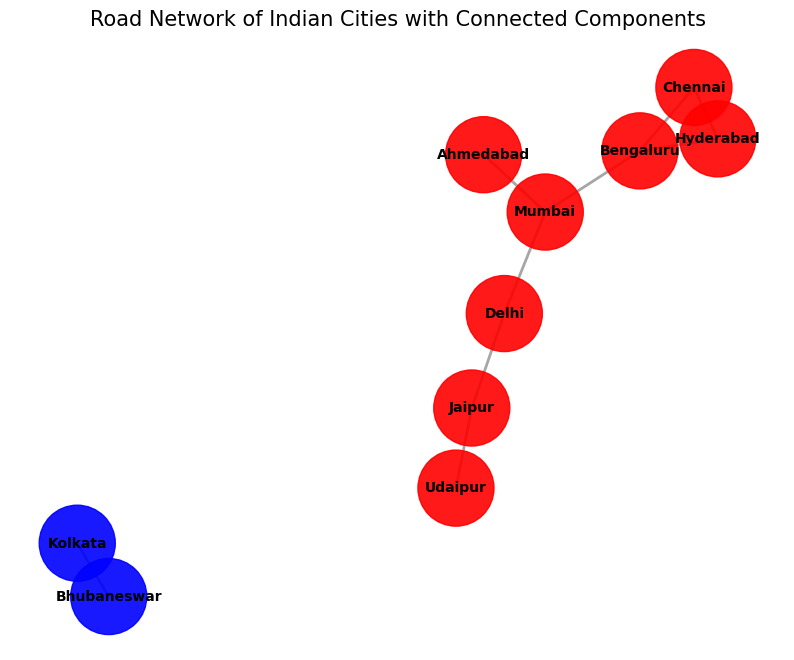

In [7]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a graph object
G = nx.Graph()

# Add nodes (cities) to the graph
G.add_nodes_from(road_network.keys())

# Add edges (roads) to the graph
for city, connections in road_network.items():
    for connected_city in connections:
        G.add_edge(city, connected_city)

# Prepare colors for connected components
# We'll assign a unique color to each component
colors = ['red', 'blue', 'green', 'purple', 'orange', 'cyan', 'magenta', 'yellow', 'lime', 'pink']
node_colors = []

for node in G.nodes():
    found_component = False
    for i, component in enumerate(connected_groups):
        if node in component:
            node_colors.append(colors[i % len(colors)])
            found_component = True
            break
    if not found_component:
        node_colors.append('gray') # Default color for any unassigned nodes (shouldn't happen here)

# Draw the graph
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G) # Layout for better visualization
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=3000, alpha=0.9)
nx.draw_networkx_edges(G, pos, width=2, alpha=0.7, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', font_color='black')

plt.title('Road Network of Indian Cities with Connected Components', size=15)
plt.axis('off') # Hide axes
plt.show()